In [1]:
import joblib
import pandas as pd

In [2]:
bundle = joblib.load(r'D:\home loan credit risk\artifact\model\model.pkl')
model = bundle['model']
features = bundle['features']

In [3]:
calibrated_model = bundle['calibrated_model']

In [4]:
df = pd.read_csv(r'D:\home loan credit risk\artifact\scorecard\scored_train.csv')

In [5]:
scorecard = pd.read_csv(r'D:\home loan credit risk\artifact\scorecard\scorecard_table.csv')

In [11]:
df.head(3)

,CODE_GENDER,AMT_CREDIT,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,REGION_RATING_CLIENT_W_CITY,EXT_SOURCE_1,EXT_SOURCE_3,FLAG_DOCUMENT_3,...,IP_NUM_COMPLETED_LOANS,PA_AVG_AMT_ANNUITY_POS,PA_RATIO_CREDIT_APPLICATION_POS,PA_RATIO_CREDIT_APPLICATION_Cash,PA_RATIO_APPROVED_LOANS,PA_AVG_RISK_WEIGHT_1080D,CB_WT_CREDIT_UTIL_TREND_3M_12M,CB_AVG_ATM_WITHDRAWAL_FREQ_6M,credit_score,TARGET
0,F,227520.0,180000.0,Commercial associate,Higher education,Married,2,0.384582,0.622922,1,...,5.0,4726.665,0.958164,1.136703,1.0,3.0,-0.06457,0.0,730.68,0
1,M,161730.0,135000.0,Commercial associate,NaN,Married,3,NaN,NaN,1,...,4.0,9049.151,1.024944,1.132000,0.8,2.8,-99999.00000,-99999.0,706.16,0
2,M,728847.0,553500.0,Working,NaN,Single,2,NaN,0.598926,1,...,1.0,12991.005,0.929718,-99999.000000,1.0,-99999.0,-99999.00000,-99999.0,723.17,1


In [13]:
scorecard.head(2)

,score_decile,count,bad_count,non_calibration,non_calibration_avg_pd_pct,good_count,pd_model_pct,observed_dr_pct,bad_capture_rate_cumsum
0,"(611.269, 690.58]",24602,6398,0.789331,78.93,18204,26.60,26.01,32.22
1,"(690.58, 704.98]",24605,3802,0.656971,65.70,20803,14.95,15.45,51.36


In [15]:
scorecard = scorecard.rename(columns={
    'non_calibration_avg_pd_pct': 'avg_predicted_pd_pct_non_calibrated',
    'pd_model_pct': 'avg_predicted_pd_pct_calibrated',
    'observed_dr_pct': 'actual_default_rate_pct'
})

In [18]:
scorecard[['score_decile','avg_predicted_pd_pct_non_calibrated','avg_predicted_pd_pct_calibrated','actual_default_rate_pct']]

,score_decile,avg_predicted_pd_pct_non_calibrated,avg_predicted_pd_pct_calibrated,actual_default_rate_pct
0,"(611.269, 690.58]",78.93,26.60,26.01
1,"(690.58, 704.98]",65.70,14.95,15.45
2,"(704.98, 715.77]",56.22,10.50,11.00
3,"(715.77, 724.79]",48.25,7.83,7.79
4,"(724.79, 733.065]",41.31,6.02,6.09
5,"(733.065, 740.96]",35.25,4.71,4.71
6,"(740.96, 749.0]",29.82,3.71,3.63
7,"(749.0, 757.81]",24.64,2.88,2.71
8,"(757.81, 769.0]",19.52,2.15,1.96
9,"(769.0, 819.41]",13.14,1.36,1.37


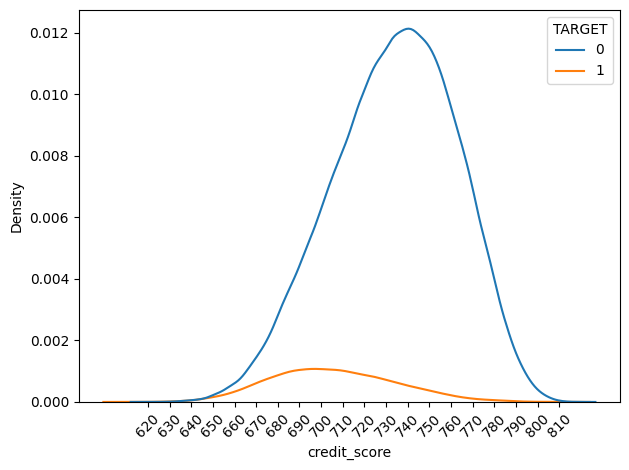

In [8]:

sns.kdeplot(data=df, x='credit_score', hue='TARGET')

plt.xticks(range(620, 820, 10))  # every 10 points
plt.xticks(rotation=45)           # rotate so they don't overlap
plt.tight_layout()
plt.show()

In [9]:
bad_loss   = 0.70   # lgd assumption rate
good_gain  = 0.06  # net margin assumption

# For each decile calculate expected value
scorecard['expected_value'] = (
    (1 - scorecard['pd_model_avg']) * good_gain -
    scorecard['pd_model_avg'] * bad_loss
)

scorecard[['score_decile', 'pd_model_avg', 'expected_value']]

,score_decile,pd_model_avg,expected_value
0,"(611.269, 690.58]",0.265978,-0.142143
1,"(690.58, 704.98]",0.149514,-0.053631
2,"(704.98, 715.77]",0.104973,-0.019779
3,"(715.77, 724.79]",0.078326,0.000473
4,"(724.79, 733.065]",0.060239,0.014219
5,"(733.065, 740.96]",0.047150,0.024166
6,"(740.96, 749.0]",0.037130,0.031781
7,"(749.0, 757.81]",0.028803,0.038110
8,"(757.81, 769.0]",0.021528,0.043639
9,"(769.0, 819.41]",0.013604,0.049661


* approve_score cut off : 724<br>
* I set the cutoff above the breakeven point to stay profitable even if default rates rise during a bad economy

In [10]:
from scipy.stats import ks_2samp

good_scores = df[df['TARGET']==0]['credit_score']
bad_scores  = df[df['TARGET']==1]['credit_score']

ks_stat, _ = ks_2samp(good_scores, bad_scores)
print(f"KS Statistic: {ks_stat:.4f}")

KS Statistic: 0.3826
